In [2]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/Passive"

In [33]:
import mat73
import os
def load_timeline(db):    
    mname, datexp, blk = db['mname'], db['datexp'], db['blk']
    root = os.path.join('Z:/data/PROC', mname, datexp, blk)
    fname     = 'Timeline_%s_%s_%s_RAW.mat'%(mname, datexp, blk) 
    fnamepath = os.path.join(root, fname) 
    data = mat73.loadmat(fnamepath, verbose=False)
    return data

In [3]:
db_ = []
db_.append({'mname': 'VG56', 'datexp': '2026_07_13', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_14', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_14', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG70', 'datexp': '2026_08_12', 'blk':'4','stim':'8x4textures'})
db_.append({'mname': 'VG69', 'datexp': '2026_08_12', 'blk':'4','stim':'8x4textures'})
db_.append({'mname': 'VG66', 'datexp': '2026_08_12', 'blk':'3','stim':'8x4textures'})
db_.append({'mname': 'VG64', 'datexp': '2026_08_12', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG63', 'datexp': '2026_08_12', 'blk':'2','stim':'8x4textures'})

ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)
ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


Average running speed: 21.74 cm/s


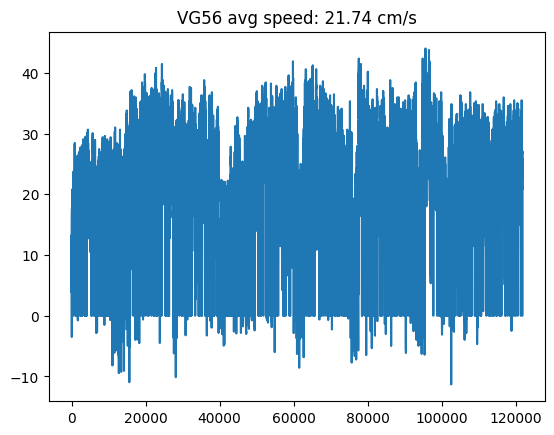

Average running speed: 14.56 cm/s


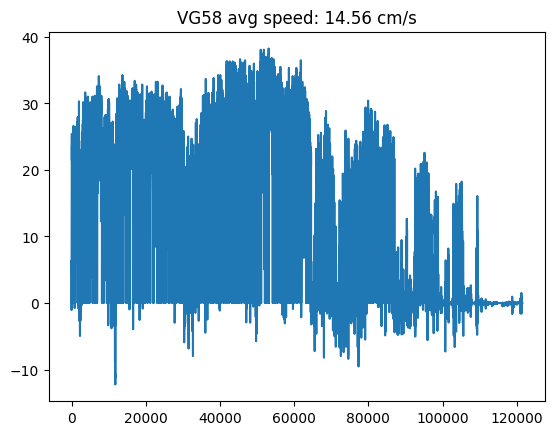

Average running speed: 20.87 cm/s


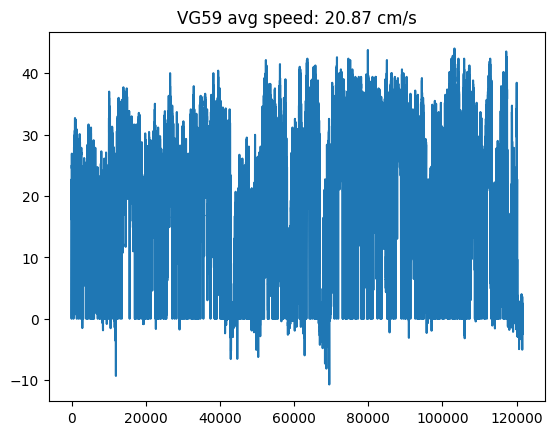

Average running speed: -624.95 cm/s


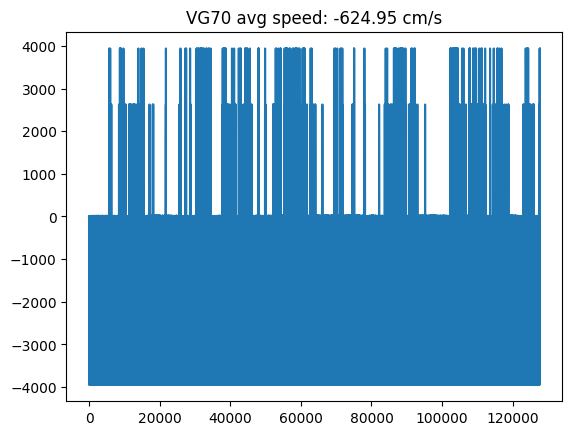

Average running speed: -561.10 cm/s


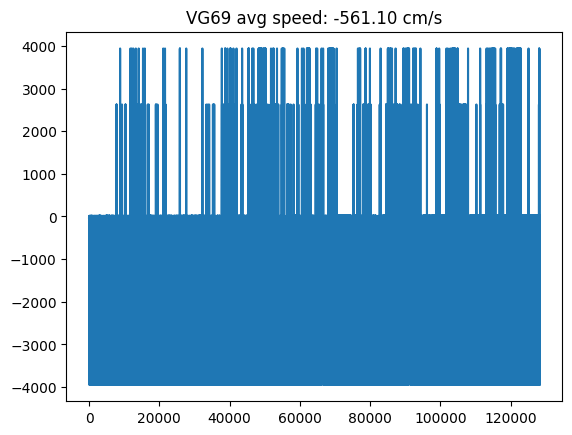

Average running speed: -575.89 cm/s


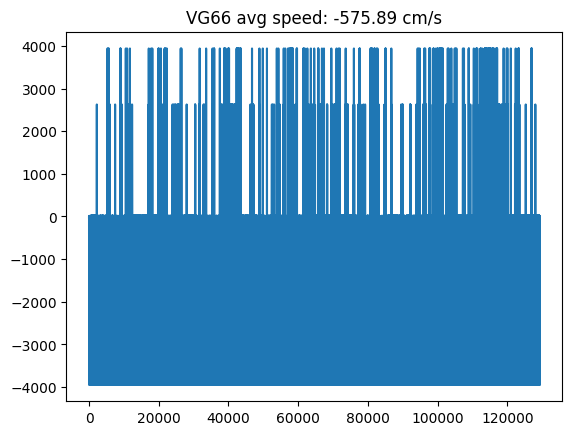

Average running speed: 3.52 cm/s


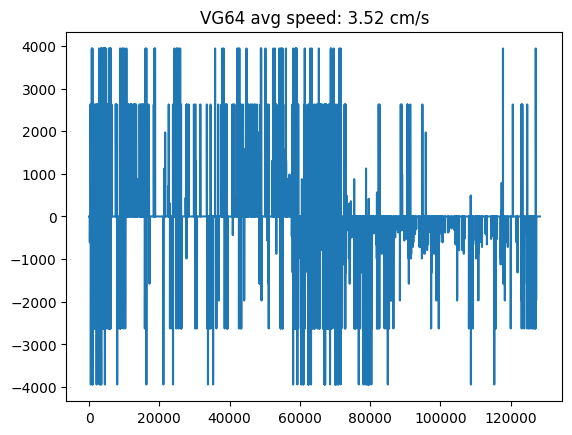

Average running speed: 0.60 cm/s


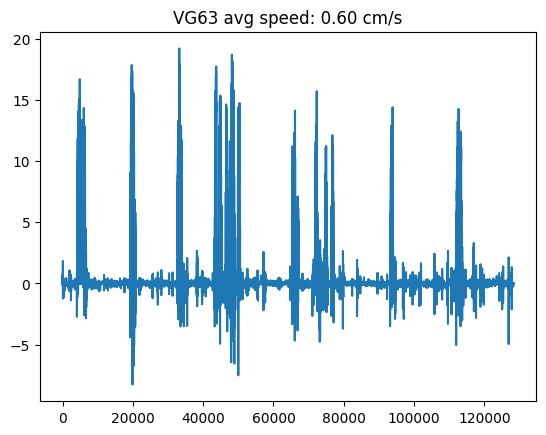

In [39]:
vg_avg_speeds = np.zeros(len(db_))
for iexp in range(len(db_)):
    timeline = load_timeline(db_[iexp])["TL"]
    run = timeline["beh"]["run_speed"] * - (1/100)
    avg_run = np.mean(run)
    mov_run = np.convolve(run, np.ones(100)/100, mode='same')
    print("Average running speed: %.2f cm/s" % avg_run)
    vg_avg_speeds[iexp] = avg_run
    plt.title(f"{db_[iexp]['mname']} avg speed: {avg_run:.2f} cm/s")
    plt.plot(run, label=db_[iexp]['mname'])
    plt.show()

In [30]:
timeline = load_timeline(db_[4])["TL"]
run = timeline["beh"]["run_speed"] * - (1/100)
avg_run = np.mean(run)
mov_run = np.convolve(run, np.ones(100)/100, mode='same')
print("Average running speed: %.2f cm/s" % avg_run)

ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)
ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


Average running speed: -561.10 cm/s


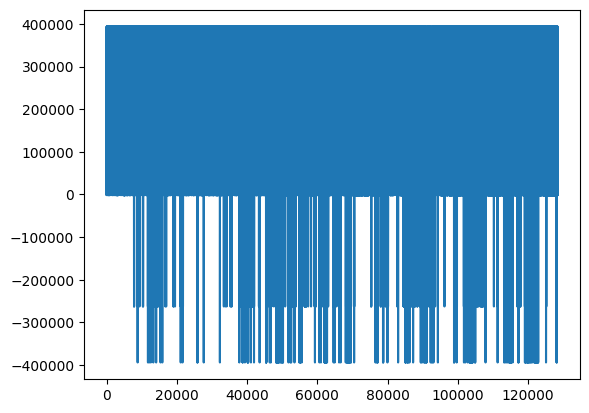

In [31]:
plt.plot(timeline["beh"]["run_speed"])